急峻な変化が多く、微分係数がとんでもないので、勾配は考慮しない

4層

学習を開始します...
Epoch 500: Loss 5.544066e-02 | LR 0.002500
Epoch 1000: Loss 1.039547e-02 | LR 0.001250
Epoch 1500: Loss 3.751488e-03 | LR 0.001250
Epoch 2000: Loss 2.276329e-03 | LR 0.000625
Epoch 2500: Loss 1.580818e-03 | LR 0.000625
Epoch 3000: Loss 1.154789e-03 | LR 0.000625
Epoch 3500: Loss 1.213443e-03 | LR 0.000625
Epoch 4000: Loss 7.593469e-04 | LR 0.000625
Epoch 4500: Loss 5.930182e-04 | LR 0.000625
Epoch 5000: Loss 3.907230e-04 | LR 0.000313
訓練が完了しました。
Max Relative Error: 0.029837


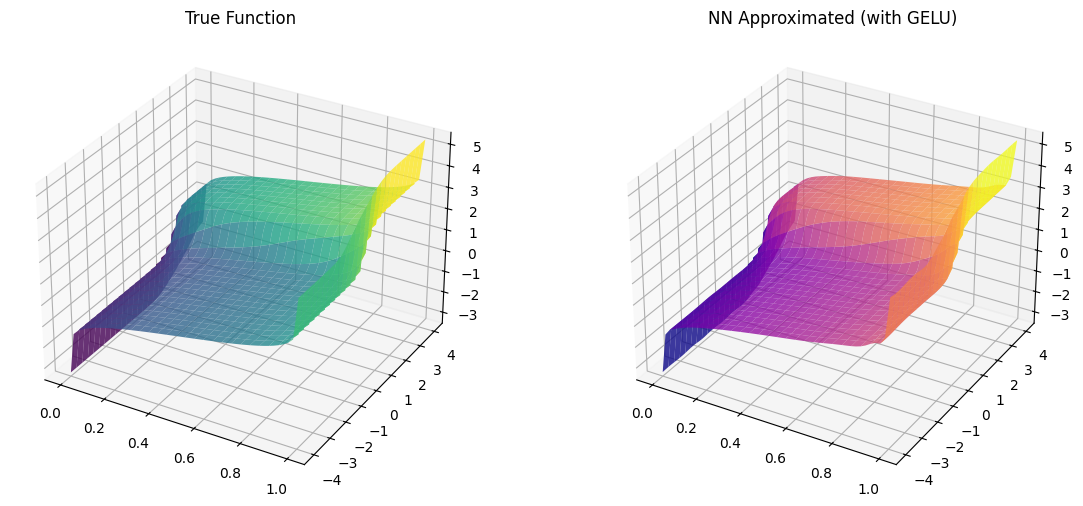

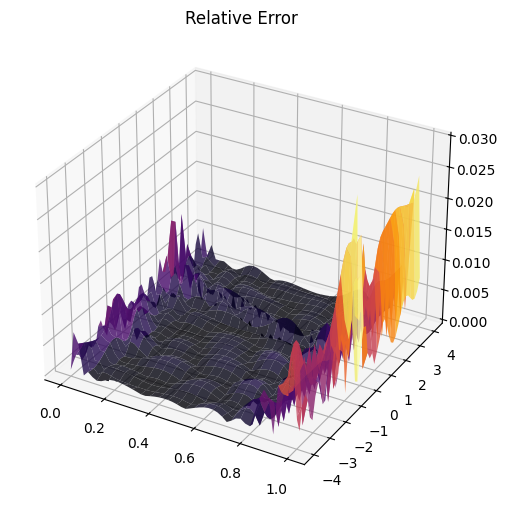

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *

f = fast_inv_F_Y_given_X

# 2. データ生成 (純粋な値のフィッティングのためrequires_gradは不要)
grid_size = 50
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# ターゲット関数の評価
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# 定数テンソルとして PyTorch に変換
features = torch.tensor(np.stack([x_flat, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (学習領域と完全に一致)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with GELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

8層

学習を開始します...
Epoch 500: Loss 7.118108e-02 | LR 0.001250
Epoch 1000: Loss 3.074421e-02 | LR 0.000313
Epoch 1500: Loss 1.114423e-02 | LR 0.000313
Epoch 2000: Loss 6.995903e-03 | LR 0.000313
Epoch 2500: Loss 4.226236e-03 | LR 0.000313
Epoch 3000: Loss 1.118512e-03 | LR 0.000313
Epoch 3500: Loss 7.220223e-04 | LR 0.000313
Epoch 4000: Loss 1.246278e-03 | LR 0.000313
Epoch 4500: Loss 3.443308e-04 | LR 0.000156
Epoch 5000: Loss 2.709941e-04 | LR 0.000156
訓練が完了しました。
Max Relative Error: 0.027395


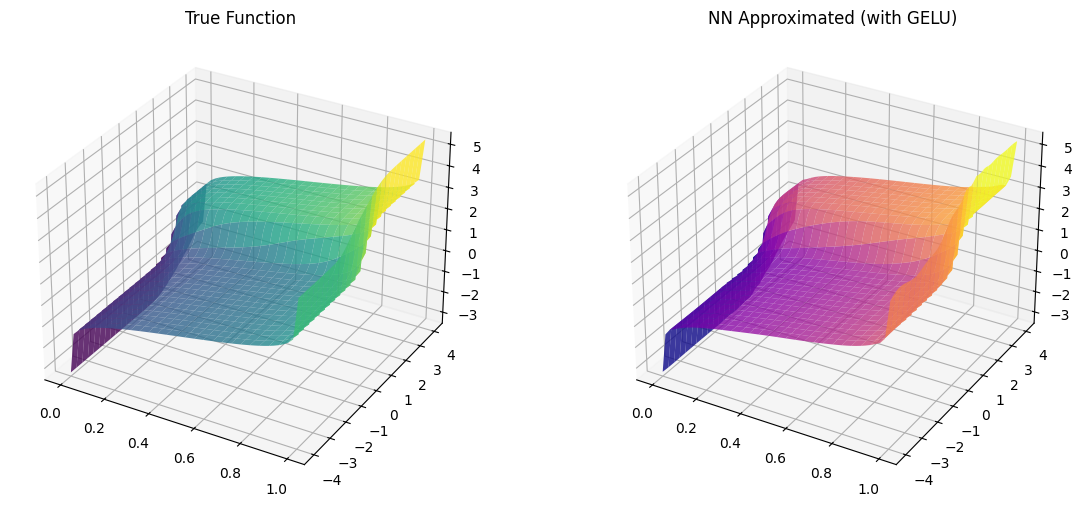

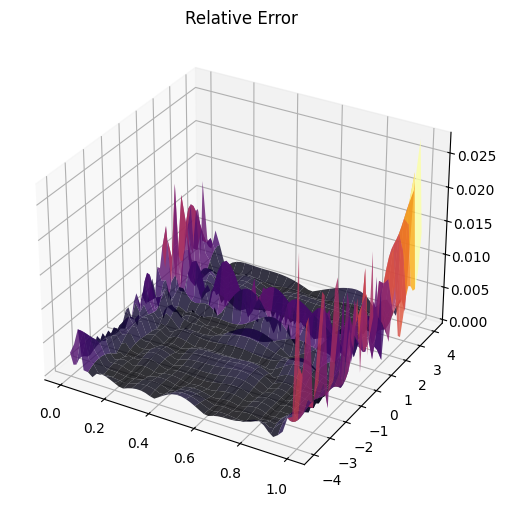

In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *

f = fast_inv_F_Y_given_X

# 2. データ生成 (純粋な値のフィッティングのためrequires_gradは不要)
grid_size = 50
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# ターゲット関数の評価
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# 定数テンソルとして PyTorch に変換
features = torch.tensor(np.stack([x_flat, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (学習領域と完全に一致)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with GELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

4層でgridsize=100で

学習を開始します...
Epoch 500: Loss 4.387520e-02 | LR 0.005000
Epoch 1000: Loss 2.609351e-02 | LR 0.002500
Epoch 1500: Loss 5.254428e-03 | LR 0.001250
Epoch 2000: Loss 3.016830e-03 | LR 0.000625
Epoch 2500: Loss 1.559686e-03 | LR 0.000625
Epoch 3000: Loss 1.314963e-03 | LR 0.000625
Epoch 3500: Loss 5.484574e-04 | LR 0.000625
Epoch 4000: Loss 4.473569e-04 | LR 0.000625
Epoch 4500: Loss 2.645323e-04 | LR 0.000313
Epoch 5000: Loss 2.058525e-04 | LR 0.000313
訓練が完了しました。
Max Relative Error: 0.025523


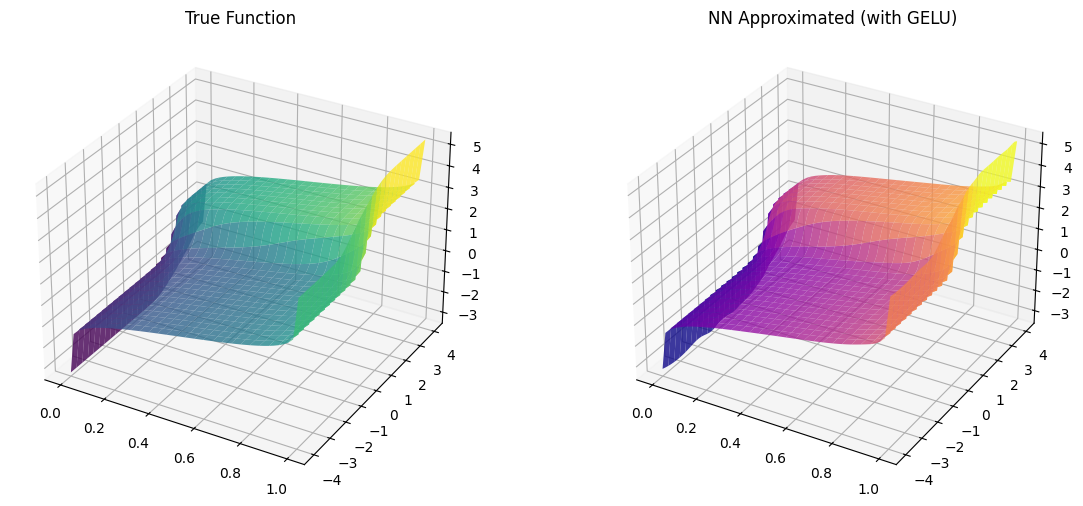

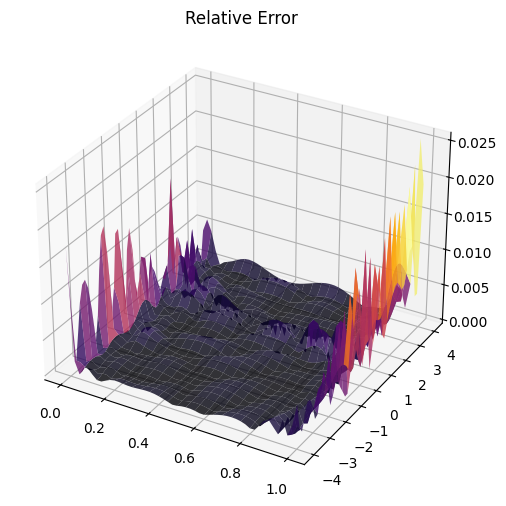

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *

f = fast_inv_F_Y_given_X

# 2. データ生成 (純粋な値のフィッティングのためrequires_gradは不要)
grid_size = 100
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# ターゲット関数の評価
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# 定数テンソルとして PyTorch に変換
features = torch.tensor(np.stack([x_flat, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    # スケジューラに純粋な数値を報告
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (学習領域と完全に一致)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with GELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

probit変換

学習を開始します...
Epoch 500: Loss 6.023217e-04 | LR 0.005000
Epoch 1000: Loss 1.848427e-05 | LR 0.005000
Epoch 1500: Loss 1.200148e-05 | LR 0.002500
Epoch 2000: Loss 8.945790e-06 | LR 0.002500
Epoch 2500: Loss 7.024096e-06 | LR 0.002500
Epoch 3000: Loss 6.022407e-06 | LR 0.001250
Epoch 3500: Loss 5.082127e-06 | LR 0.001250
Epoch 4000: Loss 4.233274e-06 | LR 0.001250
Epoch 4500: Loss 3.680775e-06 | LR 0.001250
Epoch 5000: Loss 3.226343e-06 | LR 0.000625
訓練が完了しました。
Max Relative Error: 0.002310


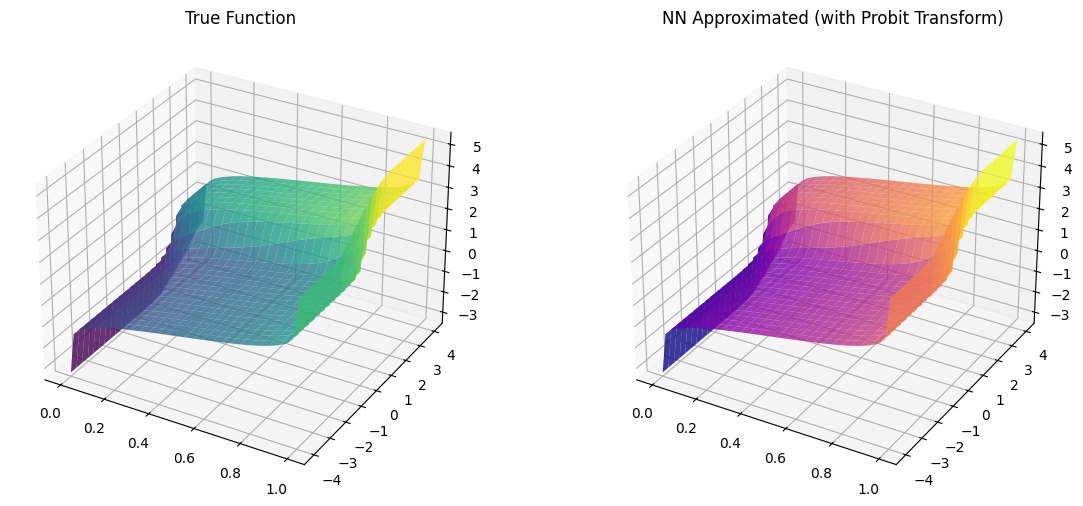

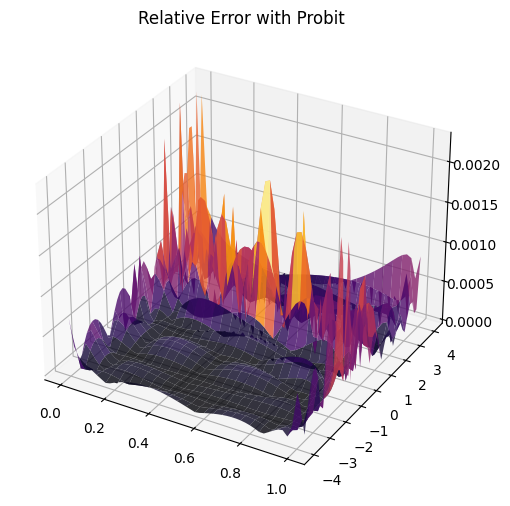

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
grid_size = 50
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()

学習を開始します...
Epoch 500: Loss 2.220113e-04 | LR 0.005000
Epoch 1000: Loss 6.255841e-05 | LR 0.005000
Epoch 1500: Loss 3.142281e-05 | LR 0.005000
Epoch 2000: Loss 2.137604e-05 | LR 0.002500
Epoch 2500: Loss 1.591381e-05 | LR 0.002500
Epoch 3000: Loss 1.234490e-05 | LR 0.002500
Epoch 3500: Loss 1.132282e-05 | LR 0.000625
Epoch 4000: Loss 1.079148e-05 | LR 0.000313
Epoch 4500: Loss 1.028182e-05 | LR 0.000313
Epoch 5000: Loss 9.749388e-06 | LR 0.000313
訓練が完了しました。
Max Relative Error: 0.004455


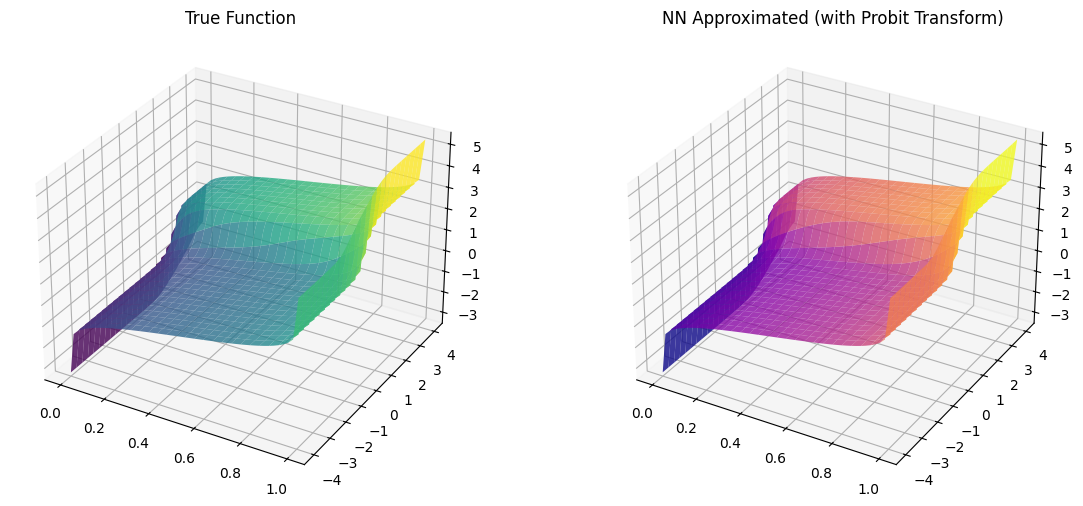

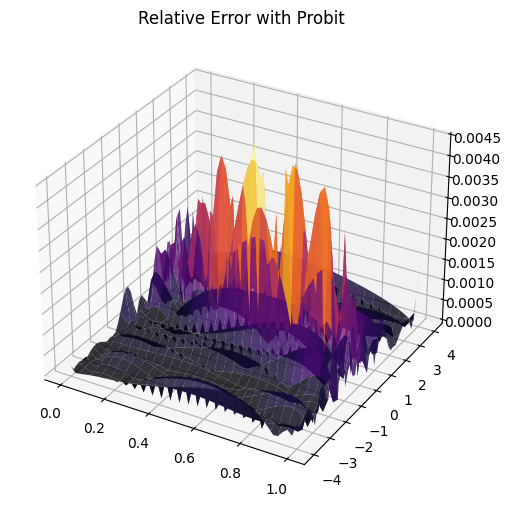

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成 (probit 空間で等間隔にサンプリング)
grid_size = 50
y_coord = np.linspace(-4.0, 4.0, grid_size)

# x のサンプリングを [1e-6, 1-1e-6] の linspace ではなく、
# probit 空間の範囲 [-4.75, 4.75]（ndtri(1e-6)≒-4.75）で均等に打つ
x_probit_min = ndtri(1e-6)
x_probit_max = ndtri(1 - 1e-6)
x_probit_coord = np.linspace(x_probit_min, x_probit_max, grid_size)

# probit 空間上で 2次元メッシュを作る
X_probit_mesh, Y_mesh = np.meshgrid(x_probit_coord, y_coord, indexing='ij')

# ターゲット関数 f に渡すための「生の x」を逆算 (標準正規分布の CDF: scipy.stats.norm.cdf など)
from scipy.stats import norm
X_mesh = norm.cdf(X_probit_mesh)

# ターゲット関数の評価
z_true = f(X_mesh, Y_mesh)

# フラット化して NN への入力にする
features = torch.tensor(np.stack([X_probit_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(z_true.ravel(), dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()

戻して、PRobit x 幅を増やす

学習を開始します...
Epoch 500: Loss 6.195486e-05 | LR 0.005000
Epoch 1000: Loss 1.278337e-05 | LR 0.005000
Epoch 1500: Loss 6.883898e-06 | LR 0.002500
Epoch 2000: Loss 3.686509e-06 | LR 0.002500
Epoch 2500: Loss 2.283721e-06 | LR 0.002500
Epoch 3000: Loss 2.321058e-06 | LR 0.000078
Epoch 3500: Loss 2.293044e-06 | LR 0.000005
Epoch 4000: Loss 2.292191e-06 | LR 0.000000
Epoch 4500: Loss 2.292188e-06 | LR 0.000000
Epoch 5000: Loss 2.292184e-06 | LR 0.000000
訓練が完了しました。
Max Relative Error: 0.002046


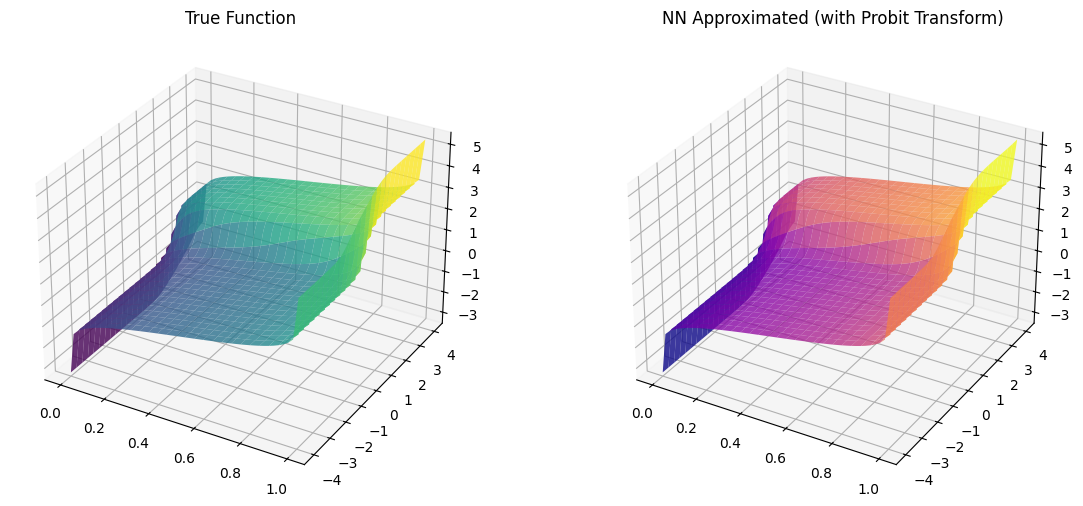

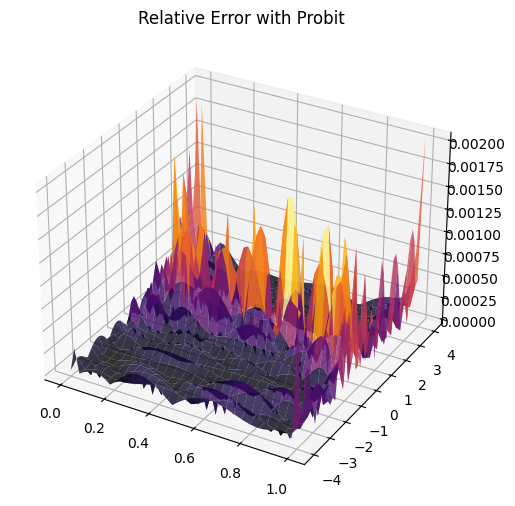

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
grid_size = 50
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()


学習を開始します...
Epoch 500: Loss 3.616336e-05 | LR 0.005000
Epoch 1000: Loss 7.632225e-05 | LR 0.005000
Epoch 1500: Loss 6.086090e-06 | LR 0.005000
Epoch 2000: Loss 2.249554e-06 | LR 0.005000
Epoch 2500: Loss 2.945024e-06 | LR 0.005000
Epoch 3000: Loss 6.639757e-04 | LR 0.005000
Epoch 3500: Loss 1.470292e-03 | LR 0.005000
Epoch 4000: Loss 1.170294e-06 | LR 0.005000
Epoch 4500: Loss 2.493291e-05 | LR 0.005000
Epoch 5000: Loss 8.243945e-06 | LR 0.005000
訓練が完了しました。
Max Relative Error: 0.006387


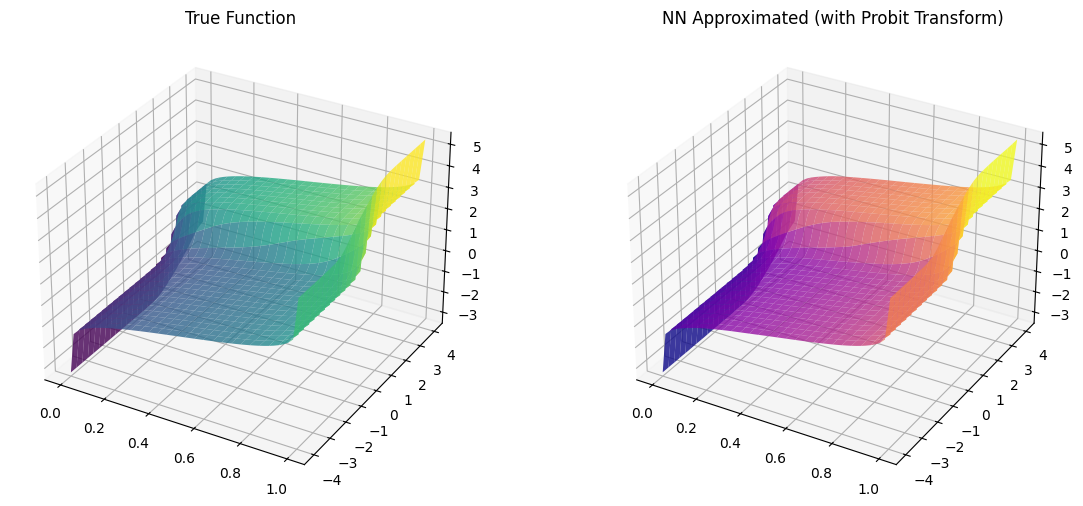

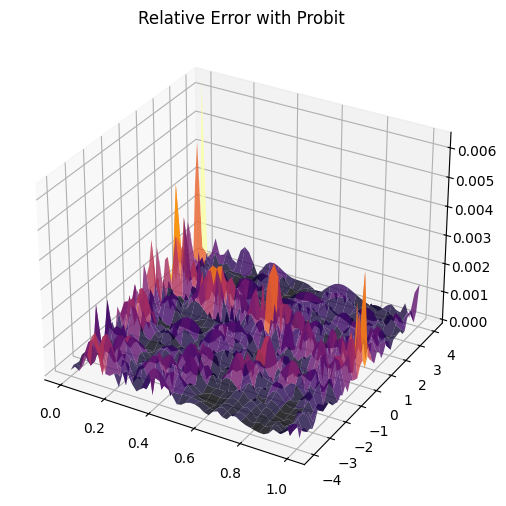

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
grid_size = 50
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()


Epoch 500: Loss 6.655981e-05 | LR 0.002000
Epoch 1000: Loss 9.940241e-06 | LR 0.002000
Epoch 1500: Loss 3.981700e-06 | LR 0.002000
Epoch 2000: Loss 4.818720e-06 | LR 0.000200
Epoch 2500: Loss 3.726927e-06 | LR 0.000200
Epoch 3000: Loss 3.070014e-06 | LR 0.000200
Epoch 3500: Loss 2.576262e-06 | LR 0.000200
Epoch 4000: Loss 2.182588e-06 | LR 0.000020
Epoch 4500: Loss 2.142596e-06 | LR 0.000020
Epoch 5000: Loss 2.094481e-06 | LR 0.000020
訓練が完了しました。
Max Relative Error: 0.001857


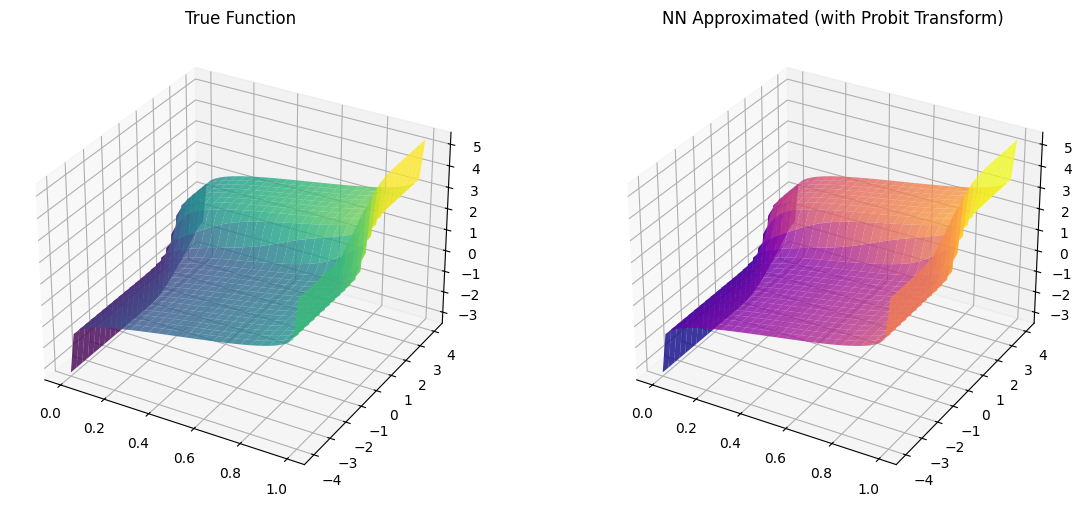

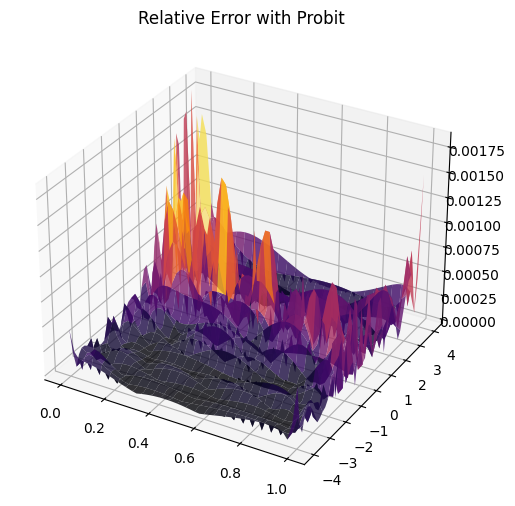

In [18]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
grid_size = 50
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
# スケジューラを自動減衰（Plateau）から、エポック数指定（MultiStepLR）に変更
# 2000エポックで大枠を学ばせ、後半は10分の1の細かさ（固定）で境界をじっくり詰めさせる
optimizer = optim.Adam(model.parameters(), lr=0.002)
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[2000, 4000],  # 2000エポックと4000エポックの瞬間にのみLRを変更
    gamma=0.1                # 学習率を10分の1にする
)

# 訓練ループ内の修正
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    # 【変更】Lossに依存せず、エポック数に応じて一律でステップを進める
    scheduler.step()
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")
        
print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
grid_size = 50
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, grid_size)
y_coord = np.linspace(-4.0, 4.0, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()


学習を開始します...
Epoch 500: Loss 7.603030e-05 | LR 0.002000
Epoch 1000: Loss 2.607585e-04 | LR 0.002000
Epoch 1500: Loss 6.918880e-06 | LR 0.002000


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils.target_functions import *
# probit変換（標準正規分布の逆関数）の計算用
from scipy.special import ndtri

f = fast_inv_F_Y_given_X

# 2. データ生成
Nv,Nx = 100,100
# 端点 0, 1 での ndtri の無限大発散を避けるため、1e-6 のバッファを維持
x_coord = np.linspace(1e-6, 1 - 1e-6, Nv)
y_coord = np.linspace(-4.0, 4.0, Nx)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord, indexing='ij')

x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()

# 【重要】x を probit 空間（実数全体）に変換
x_probit = ndtri(x_flat)

# ターゲット関数の評価（真の値の計算にはオリジナルの座標を使用）
z_true = f(X_mesh, Y_mesh)
z_flat = z_true.ravel()

# NNへの入力は [x_probit, y_flat] に差し替え
features = torch.tensor(np.stack([x_probit, y_flat], axis=1), dtype=torch.float32)
labels = torch.tensor(z_flat, dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU 4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.002)
criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")

for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    
    loss.backward()
    optimizer.step()
    
    scheduler.step(loss.item())
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数（入力時にprobit変換を挟む）
def f_approx(x, y):
    # 与えられた x を probit 空間に変換してから NN に流す
    x_probit_eval = ndtri(np.array(x).ravel())
    coords = torch.tensor(np.stack([x_probit_eval, np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析 (同一の定義域で評価)
n_eval = 51
x_eval = np.linspace(1e-6, 1 - 1e-6, n_eval)
y_eval = np.linspace(-4.0, 4.0, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')

f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Probit Transform)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error with Probit")

plt.show()
